In [2]:
# PART 1: THE TENSOR CLASS
#
# WHAT IS THIS?
#   A tiny homemade version of what PyTorch Tensors do:
#     1) store numbers (data)
#     2) remember HOW those numbers were computed (a graph of ops)
#     3) when you call .backward(), automatically compute gradients
#        (how much each input should change to increase/decrease the result)
#
# WHY?
#   Training a neural net = "nudge weights opposite the gradient."
#   This Tensor class is the engine that finds those gradients for you
#   using the chain rule (backpropagation).
#
# Kid picture:
#   Forward: mix ingredients → get a cake score
#   Backward: figure out "if I change sugar a tiny bit, how does the score change?"

# Basic Tensor with Gradient Tracking

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


def _reduce_grad(grad, shape):
    """Sum away axes that were introduced by NumPy broadcasting.
    Example: bias b shape (1,) added to (4,1) → incoming grad (4,1) must become (1,).
    """
    grad = np.asarray(grad, dtype=np.float64)
    # Extra leading dims (rare here, but safe)
    while grad.ndim > len(shape):
        grad = grad.sum(axis=0)
    # Dims that were size-1 and got expanded
    for axis, size in enumerate(shape):
        if size == 1 and grad.shape[axis] > 1:
            grad = grad.sum(axis=axis, keepdims=True)
    return grad.reshape(shape)


class Tensor:
    """
    Minimal Tensor with automatic differentiation
    (inspired by micrograd / PyTorch).
    """
    def __init__(self, data, children=(), op='', requires_grad=False):
        self.data = np.array(data, dtype=np.float64)  # the actual numbers
        # grad = "sensitivity": how the final loss changes if this tensor changes
        self.grad = np.zeros_like(self.data) if requires_grad else None
        self.requires_grad = requires_grad            # True for weights we want to learn
        self._backward = lambda: None                 # function that pushes grad to parents
        self._prev = set(children)                    # tensors this one was built from
        self._op = op                                 # '+', '*', 'ReLU', ... (for debugging)

    @property
    def shape(self):
        # Match NumPy/PyTorch: t.shape instead of t.data.shape
        return self.data.shape

    def __repr__(self):
        return f"Tensor(data={self.data}, grad={self.grad}, op='{self._op}')"

    def backward(self):
        # 1) Order all nodes so parents come before children (topological sort)
        #    Then we walk REVERSED: children → parents (true backpropagation order)
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # 2) Seed: d(final)/d(final) = 1
        self.grad = np.ones_like(self.data)

        # 3) Apply each node's local chain-rule rule
        for v in reversed(topo):
            v._backward()

    # --- Basic arithmetic ---
    # Pattern for every op:
    #   - compute forward value into `out`
    #   - define _backward that sends out.grad back to inputs using the derivative

    def __add__(self, other):
        # c = a + b  →  dc/da = 1, dc/db = 1
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(
            self.data + other.data,
            (self, other),
            '+',
            requires_grad=self.requires_grad or other.requires_grad,
        )
        def _backward():
            if self.requires_grad:
                self.grad += _reduce_grad(out.grad, self.data.shape)
            if other.requires_grad:
                other.grad += _reduce_grad(out.grad, other.data.shape)
        out._backward = _backward
        return out

    def __mul__(self, other):
        # c = a * b  →  dc/da = b, dc/db = a
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(
            self.data * other.data,
            (self, other),
            '*',
            requires_grad=self.requires_grad or other.requires_grad,
        )
        def _backward():
            if self.requires_grad:
                self.grad += _reduce_grad(other.data * out.grad, self.data.shape)
            if other.requires_grad:
                other.grad += _reduce_grad(self.data * out.grad, other.data.shape)
        out._backward = _backward
        return out

    def __matmul__(self, other):
        """Matrix multiply: self @ other  (used for neural net layers)"""
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(
            self.data @ other.data,
            (self, other),
            '@',
            requires_grad=self.requires_grad or other.requires_grad,
        )
        def _backward():
            if self.requires_grad:
                # dL/d(self) = dL/d(out) @ other.T
                self.grad += out.grad @ other.data.T
            if other.requires_grad:
                # dL/d(other) = self.T @ dL/d(out)
                other.grad += self.data.T @ out.grad
        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __truediv__(self, other):
        return self * (other ** -1)

    def __pow__(self, power):
        # c = a ** p  →  dc/da = p * a**(p-1)
        assert isinstance(power, (int, float))
        out = Tensor(
            self.data ** power,
            (self,),
            f'**{power}',
            requires_grad=self.requires_grad,
        )
        def _backward():
            if self.requires_grad:
                self.grad += power * (self.data ** (power - 1)) * out.grad
        out._backward = _backward
        return out

    # --- Activations (nonlinear "on/off" transforms) ---

    def relu(self):
        # ReLU: keep positives, zero out negatives
        # derivative is 1 if x>0 else 0
        out = Tensor(np.maximum(0, self.data), (self,), 'ReLU', requires_grad=self.requires_grad)
        def _backward():
            if self.requires_grad:
                self.grad += (self.data > 0) * out.grad
        out._backward = _backward
        return out

    def sigmoid(self):
        # Squash any number into (0, 1) — useful for probabilities
        s = 1 / (1 + np.exp(-self.data))
        out = Tensor(s, (self,), 'Sigmoid', requires_grad=self.requires_grad)
        def _backward():
            if self.requires_grad:
                self.grad += s * (1 - s) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        # Squash into (-1, 1)
        t = np.tanh(self.data)
        out = Tensor(t, (self,), 'Tanh', requires_grad=self.requires_grad)
        def _backward():
            if self.requires_grad:
                self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out

    # --- Reductions (many numbers → one number; needed for a scalar loss) ---

    def sum(self):
        out = Tensor(np.sum(self.data), (self,), 'sum', requires_grad=self.requires_grad)
        def _backward():
            if self.requires_grad:
                # sum's gradient spreads equally back to every element
                self.grad += np.ones_like(self.data) * out.grad
        out._backward = _backward
        return out

    def mean(self):
        n = self.data.size
        out = Tensor(np.mean(self.data), (self,), 'mean', requires_grad=self.requires_grad)
        def _backward():
            if self.requires_grad:
                self.grad += np.ones_like(self.data) * (out.grad / n)
        out._backward = _backward
        return out


# --- Quick test: c = a*b + a ---
# Math: dc/da = b + 1 = 4,  dc/db = a = 2
a = Tensor([2.0], requires_grad=True)
b = Tensor([3.0], requires_grad=True)
c = a * b + a
c.backward()
print("c =", c.data)
print("a.grad =", a.grad, "(should be b+1 = 4)")
print("b.grad =", b.grad, "(should be a = 2)")
# If those match, forward + backward graph is working.

# You just built the core of PyTorch. 
# Every operation records a _backward closure that computes local gradients via the chain rule. 
# Calling .backward() triggers the whole graph.

c = [8.]
a.grad = [4.] (should be b+1 = 4)
b.grad = [2.] (should be a = 2)


In [6]:
# Testing the Autograd Engine
#
# Two checks:
#   1) Scalar graph: y = (x1 + x2) * x3  → known hand-computed grads
#   2) Matrix graph: C = A @ B, loss = sum(C) → check A.grad shape/formula
#
# If both pass, + * @ and backward() are trustworthy for building layers later.

# --- Test 1: scalar expression ---
# y = (x1 + x2) * x3
# With x1=1, x2=2, x3=3 → y = (1+2)*3 = 9
#
# Chain rule:
#   dy/dx1 = x3 = 3          (x1 only appears inside the sum, then * x3)
#   dy/dx2 = x3 = 3
#   dy/dx3 = (x1+x2) = 3
x1 = Tensor([1.0], requires_grad=True)
x2 = Tensor([2.0], requires_grad=True)
x3 = Tensor([3.0], requires_grad=True)

y = (x1 + x2) * x3
y.backward()  # fill .grad on x1, x2, x3

print("y =", y.data)  # expect 9
print("x1.grad:", x1.grad, "(dy/dx1 = x3 = 3)")
print("x2.grad:", x2.grad, "(dy/dx2 = x3 = 3)")
print("x3.grad:", x3.grad, "(dy/dx3 = x1+x2 = 3)")

# --- Test 2: matrix multiplication gradients ---
# A is (2,3), B is (3,2) → C = A @ B is (2,2)
# loss = sum of all entries of C  →  d(loss)/dC = ones(2,2)
#
# From matmul backward:
#   dL/dA = (dL/dC) @ B.T   → shape (2,2)@(2,3) = (2,3)  matches A
#   dL/dB = A.T @ (dL/dC)   → shape (3,2)@(2,2) = (3,2)  matches B
A = Tensor(np.random.randn(2, 3), requires_grad=True)
B = Tensor(np.random.randn(3, 2), requires_grad=True)
C = A @ B       # forward matmul
loss = C.sum()  # scalar so backward has a single starting grad
loss.backward()

print("\nMatrix grad test:")
# .data.shape always works (NumPy). Tensor also has .shape @property if cell 0 was run.
print("A.shape:", A.data.shape, "A.grad.shape:", A.grad.shape)
print("B.shape:", B.data.shape, "B.grad.shape:", B.grad.shape)
# True means our A.grad matches the analytic formula ones @ B.T
print("Gradient check A:", np.allclose(A.grad, np.ones((2, 2)) @ B.data.T))

# Critical: Notice how matrix multiplication gradients involve transposes. This is why shape errors plague neural network code. 
# Knowing the rule dL/dA = dL/dC @ B^T prevents most bugs.

y = [9.]
x1.grad: [3.] (dy/dx1 = x3 = 3)
x2.grad: [3.] (dy/dx2 = x3 = 3)
x3.grad: [3.] (dy/dx3 = x1+x2 = 3)

Matrix grad test:
A.shape: (2, 3) A.grad.shape: (2, 3)
B.shape: (3, 2) B.grad.shape: (3, 2)
Gradient check A: True


In [8]:
# PART 2: NEURAL NETWORK LAYERS
#
# WHAT IS THIS?
#   Building blocks that stack into a neural net — same idea as torch.nn.
#
#   Module     = base class ("any layer")
#   Linear     = y = x @ W + b   (the classic fully-connected layer)
#   ReLU / Sigmoid = nonlinear activations (so the net can learn curves, not only lines)
#   Sequential = pipe layers one after another: x → L1 → L2 → ...
#
# Kid picture:
#   Linear = mix ingredients with a recipe (weights W, bias b)
#   ReLU   = throw away negative tastes (keep only useful signal)
#   Sequential = assembly line of those steps

# Linear Layer, ReLU, Sequential

class Module:
    """Base class for all layers (like torch.nn.Module)."""
    def parameters(self):
        # Learnable Tensors (weights/biases). Default: none.
        return []

    def zero_grad(self):
        # Before each training step, clear old gradients
        # (grads accumulate with += in our Tensor backward)
        for p in self.parameters():
            p.grad = np.zeros_like(p.data)


class Linear(Module):
    """Fully connected layer: output = x @ W + b"""
    def __init__(self, in_features, out_features):
        # W shape: (in_features, out_features)
        # He/Xavier-ish scale: * sqrt(2/in) keeps initial values from exploding
        self.W = Tensor(
            np.random.randn(in_features, out_features) * np.sqrt(2.0 / in_features),
            requires_grad=True,  # we want gradients so we can learn W
        )
        self.b = Tensor(np.zeros((1, out_features)), requires_grad=True)  # row vector: broadcasts over batch

    def forward(self, x):
        # x: (batch, in_features)  →  (batch, out_features)
        return x @ self.W + self.b

    def parameters(self):
        return [self.W, self.b]


class ReLU(Module):
    """Activation: max(0, x) — zeros out negatives, passes positives."""
    def forward(self, x):
        return x.relu()


class Sigmoid(Module):
    """Activation: squash to (0, 1) — often used for binary probability output."""
    def forward(self, x):
        return x.sigmoid()


class Sequential(Module):
    """Stack layers in order. forward runs them left → right."""
    def __init__(self, *layers):
        self.layers = layers  # e.g. Linear(...), ReLU(), Linear(...)

    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)  # output of one becomes input of next
        return x

    def parameters(self):
        # Collect ALL learnable weights from every sub-layer
        # (optimizer will loop over this list)
        params = []
        for layer in self.layers:
            params.extend(layer.parameters())
        return params


# Example (conceptually):
#   model = Sequential(
#       Linear(2, 8),
#       ReLU(),
#       Linear(8, 1),
#       Sigmoid(),
#   )
#   y_hat = model.forward(x)   # prediction
#   # then loss.backward(); update each p in model.parameters()


In [11]:
# Loss Functions
#
# WHAT IS A LOSS?
#   One number that means "how wrong is the model?"
#   Training = change weights so this number goes DOWN.
#
#   After forward:  loss = some_loss(prediction, truth)
#   Then:           loss.backward()  → fills .grad on all weights
#
# Which loss when?
#   mse_loss              → predict a NUMBER (regression), e.g. house price
#   binary_cross_entropy  → predict YES/NO probability (0 or 1)
#   cross_entropy_loss    → predict ONE OF MANY classes (cat/dog/bird...)

def mse_loss(y_pred, y_true):
    """Mean Squared Error — average of (prediction - truth)^2.
    Big mistakes get punished harder because of the square.
    """
    return ((y_pred - y_true) ** 2).mean()


def binary_cross_entropy(y_pred, y_true):
    """Binary Cross-Entropy for probabilities in (0, 1).

    Idea:
      if truth=1, punish low probability  →  -log(p)
      if truth=0, punish high probability →  -log(1-p)

    Needs .log() on Tensor (patched onto the class below).
    """
    # Note: an earlier clip-into-new-Tensor approach would break the graph;
    # we rely on log() clipping internally instead.
    return -(y_true * y_pred.log() + (1 - y_true) * (1 - y_pred).log()).mean()


# --- Add log() to Tensor so BCE can backprop through it ---
# d/dx log(x) = 1/x
def tensor_log(self):
    out = Tensor(
        np.log(np.clip(self.data, 1e-7, None)),  # clip avoids log(0)
        (self,),
        'log',
        requires_grad=self.requires_grad,
    )
    def _backward():
        if self.requires_grad:
            self.grad += (1.0 / (self.data + 1e-7)) * out.grad
    out._backward = _backward
    return out

Tensor.log = tensor_log  # monkey-patch: now every Tensor has .log()


def cross_entropy_loss(logits, y_true_indices):
    """Multi-class cross-entropy from raw scores (logits).

    Steps:
      1) Softmax logits → probabilities that sum to 1 per row
      2) Pick probability of the CORRECT class
      3) loss = -mean(log(that probability))
         (if correct class has prob≈1, loss≈0; if tiny, loss is large)

    Numerically stable trick: subtract max(logit) before exp (same as earlier softmax tip).

    Backward uses the known shortcut:
      dL/d(logits) = (softmax_probs - one_hot_labels) / batch_size
    """
    n = logits.data.shape[0]  # batch size

    # Stable softmax
    shifted = logits.data - np.max(logits.data, axis=1, keepdims=True)
    exp_shifted = np.exp(shifted)
    probs = exp_shifted / np.sum(exp_shifted, axis=1, keepdims=True)

    # -log(prob of true class), averaged
    log_probs = np.log(probs[np.arange(n), y_true_indices] + 1e-7)
    loss = -np.mean(log_probs)

    # Wire into our Tensor graph so loss.backward() reaches logits
    out = Tensor(loss, requires_grad=logits.requires_grad)
    out._prev = {logits}
    out._softmax_probs = probs
    out._y_true_indices = y_true_indices

    def _backward():
        if logits.requires_grad:
            grad = probs.copy()
            grad[np.arange(n), y_true_indices] -= 1  # subtract 1 at the true class
            grad /= n
            logits.grad += grad * out.grad

    out._backward = _backward
    return out


# Quick mental check:
#   perfect prediction → loss near 0
#   confident but wrong → loss large
#   loss.backward() → tells Linear weights how to fix the next guess

# Note: We'll train on MNIST using a simpler approach: we'll manually implement the full network's backward pass. 
# That's actually more educational and you'll see exactly how cross-entropy gradients work. 
# In practice, our Tensor class can handle it, but for clarity we'll build a dedicated training loop with explicit gradient computation.

Predictions after training:
[[0.]
 [1.]
 [1.]
 [0.]]
Loss curve:


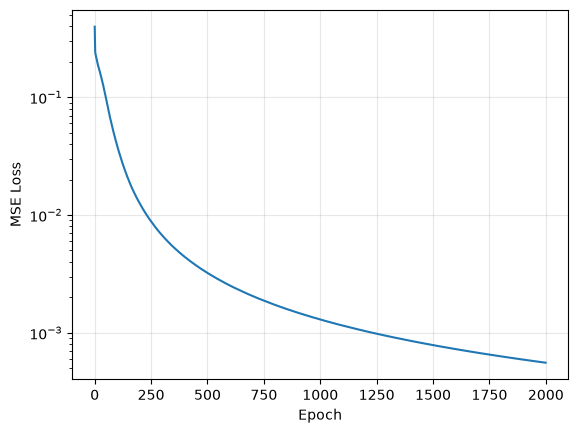

In [15]:
# PART 3: TRAINING ON XOR (Sanity Check)
#
# IMPORTANT: If you see a broadcast ValueError on loss.backward(),
# re-run the PART 1 Tensor cell first (or just run this cell — it re-applies the fix below).

# --- Ensure broadcast-safe gradients on + and * (fixes bias shape (1,) vs batch (4,1)) ---
def _reduce_grad(grad, shape):
    grad = np.asarray(grad, dtype=np.float64)
    while grad.ndim > len(shape):
        grad = grad.sum(axis=0)
    for axis, size in enumerate(shape):
        if size == 1 and grad.shape[axis] > 1:
            grad = grad.sum(axis=axis, keepdims=True)
    return grad.reshape(shape)

def _add_broadcast_safe(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(
        self.data + other.data,
        (self, other),
        '+',
        requires_grad=self.requires_grad or other.requires_grad,
    )
    def _backward():
        if self.requires_grad:
            self.grad += _reduce_grad(out.grad, self.data.shape)
        if other.requires_grad:
            other.grad += _reduce_grad(out.grad, other.data.shape)
    out._backward = _backward
    return out

def _mul_broadcast_safe(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(
        self.data * other.data,
        (self, other),
        '*',
        requires_grad=self.requires_grad or other.requires_grad,
    )
    def _backward():
        if self.requires_grad:
            self.grad += _reduce_grad(other.data * out.grad, self.data.shape)
        if other.requires_grad:
            other.grad += _reduce_grad(self.data * out.grad, other.data.shape)
    out._backward = _backward
    return out

Tensor.__add__ = _add_broadcast_safe
Tensor.__mul__ = _mul_broadcast_safe

# Test the Framework on XOR

# XOR dataset: linear model fails, 2-layer with ReLU works
np.random.seed(0)  # reproducible weights so the demo converges
X_xor = Tensor(np.array([[0.,0.],[0.,1.],[1.,0.],[1.,1.]]), requires_grad=False)
y_xor = Tensor(np.array([[0.],[1.],[1.],[0.]]), requires_grad=False)

# Model: 2 -> 8 (ReLU) -> 1 (Sigmoid)
model = Sequential(
    Linear(2, 8),
    ReLU(),
    Linear(8, 1),
    Sigmoid()
)

# Training loop
lr = 0.5
n_epochs = 2000
losses = []
for epoch in range(n_epochs):
    # Forward
    y_pred = model.forward(X_xor)
    loss = mse_loss(y_pred, y_xor)
    losses.append(loss.data)
    
    # Zero gradients
    model.zero_grad()
    
    # Backward
    loss.backward()
    
    # Update parameters manually
    for p in model.parameters():
        p.data -= lr * p.grad

# Results
print("Predictions after training:")
print(y_pred.data.round())
print("Loss curve:")
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()